In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin


In [2]:
# Load dataset
data = pd.read_csv('../M1_final.csv')

# Drop unnecessary features
data.drop(columns=['TAIL_NUM', 'DEP_TIME_M', 'TAXI_OUT'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)



# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    x_train = x.iloc[train_index]
    x_test = x.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]


class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X
    

class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X
    
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition']),
    ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore', drop='first'), ['time_of_day'])
], remainder='passthrough')

## Model

In [3]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

## create pipeline

In [4]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('Train XGBoost', xgboost_model)
])

## Optuna Hyperparameter Tuning

In [6]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# Suppress Optuna logs for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def objective(trial):
    # Define hyperparameter search space
    params = {
        'Train XGBoost__n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'Train XGBoost__max_depth': trial.suggest_int('max_depth', 3, 10),
        'Train XGBoost__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'Train XGBoost__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'Train XGBoost__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'Train XGBoost__min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'Train XGBoost__gamma': trial.suggest_float('gamma', 0, 0.5),
        'Train XGBoost__reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'Train XGBoost__reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
    }
    
    # Set parameters to the pipeline
    pipe.set_params(**params)
    
    # Perform cross-validation
    # Using accuracy as the metric
    cv_scores = cross_val_score(
        pipe, 
        x_train, 
        y_train, 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1
    )
    
    # Return mean accuracy
    return cv_scores.mean()

In [ ]:
# Create Optuna study
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    study_name='XGBoost_Hyperparameter_Tuning',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*50)
print("Optimization completed!")
print("="*50)

Starting hyperparameter optimization...


  0%|          | 0/50 [00:00<?, ?it/s]/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:14:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:14:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:14:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:14:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.


Optimization completed!


## Best Parameters and Results

In [9]:
# Display best parameters
print("Best Trial:")
print(f"  Value (Accuracy): {study.best_trial.value:.4f}")
print(f"  Number: {study.best_trial.number}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Trial:
  Value (Accuracy): 0.9112
  Number: 33

Best Hyperparameters:
  n_estimators: 462
  max_depth: 7
  learning_rate: 0.07468889167695233
  subsample: 0.8433133977413599
  colsample_bytree: 0.8651581198356619
  min_child_weight: 4
  gamma: 0.221274461259664
  reg_alpha: 0.4371325502940443
  reg_lambda: 0.4162692001156498


In [10]:
# Train final model with best parameters
best_params_with_prefix = {f'Train XGBoost__{key}': value for key, value in study.best_params.items()}
pipe.set_params(**best_params_with_prefix)

# Fit the model
print("Training final model with best parameters...")
pipe.fit(x_train, y_train)
print("Training completed!")

Training final model with best parameters...


/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:16:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training completed!


## Evaluate on Test Set

In [11]:
# Make predictions on test set
y_pred = pipe.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("Test Set Performance")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*50)

Test Set Performance
Accuracy:  0.9157
Precision: 0.8597
Recall:    0.4726
F1 Score:  0.6100


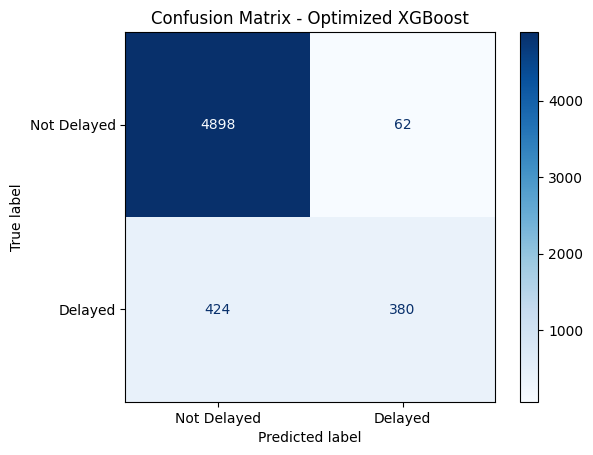

In [12]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Optimized XGBoost')
plt.show()

## Optuna Visualization

In [ ]:
# Optimization history
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

In [ ]:
# Parameter importance
fig = optuna.visualization.plot_param_importances(study)
fig.show()

In [ ]:
# Parallel coordinate plot
fig = optuna.visualization.plot_parallel_coordinate(study)
fig.show()

In [ ]:
# Slice plot for key hyperparameters
fig = optuna.visualization.plot_slice(study, params=['n_estimators', 'max_depth', 'learning_rate'])
fig.show()